Project: 멋진 챗봇 만들기

# Setting

In [1]:
!mkdir -p ~/work/transformer_chatbot/data/spa-eng

In [2]:
!python3 -m pip install --upgrade pip
!python3 -m pip install konlpy # Python 3.x
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh) # MeCab 설치하기

  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 2.6 MB/s eta 0:00:00ta 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 25.1.1
    Uninstalling pip-25.1.1:
ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: '/opt/conda/bin/pip'

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.12/site-packages/pip/__main__.py", line 22, in <module>
  File "/opt/conda/lib/python3.12/site-packages/pip/_internal/cli/main.py", line 10, in <module>
    from pip._internal.cli.autocompletion import autocomplete
  File "/opt/conda/lib/python3.12/site-packages/pip/_internal/cli/autocompletion.py", line 9, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "/opt/conda/lib/python3.12/site-packages/pip/_internal/cli/main_parser.py", 

In [3]:
!pip install sentencepiece nltk

In [87]:
import numpy as np
import pandas as pd
import torch
import nltk
import gensim

import sentencepiece as spm
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction

import re
import os
import random
import math

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(torch.__version__)

2.7.1+cu118


In [298]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

# Dataset

## Step 1. Data download

[songys/Chatbot_data](https://github.com/songys/Chatbot_data)  
- QA pair 11,876개
- colums : 'Q', 'A', 'label'
  - 'label'
    - 0 : 일상다반사 5,290개
    - 1 : 이별(부정) 3,570개
    - 2 : 사랑(긍정) 2,963개

In [1]:
import pandas as pd
dataset = pd.read_csv('~/data/ChatbotData.csv')
dataset.head()

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [2]:
dataset['label'].value_counts()

label
0    5290
1    3570
2    2963
Name: count, dtype: int64

In [3]:
total_sentence_count = len(dataset)
print("Example:", total_sentence_count)

Example: 11823


In [4]:
# train-validation-test dataset 나누기 90:9:1

from sklearn.model_selection import train_test_split

# 1️⃣ train / temp (val+test)
train_df, temp_df = train_test_split(
    dataset,
    test_size=0.1,
    stratify=dataset['label'],
    random_state=42
)

# 2️⃣ validation / test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.1,
    stratify=temp_df['label'],
    random_state=42
)

print("train:", len(train_df))
print("val:", len(val_df))
print("test:", len(test_df))

train: 10640
val: 1064
test: 119


In [120]:
import os

# 폴더 생성 (없으면 생성)
os.makedirs("chatbot", exist_ok=True)

# CSV 저장
train_df.to_csv("chatbot/train.csv", index=False)
val_df.to_csv("chatbot/val.csv", index=False)
test_df.to_csv("chatbot/test.csv", index=False)

print("train:", len(train_df))
print("val:", len(val_df))
print("test:", len(test_df))
print("CSV files saved in 'chatbot' folder")

train: 10640
val: 1064
test: 119
CSV files saved in 'chatbot' folder


## Step 2. Preprocessing & Step 3. Tokenizer

- build_corpus() 함수 구현하기
  - 소스 문장 데이터와 타겟 문장 데이터를 입력으로 받습니다.
  - 데이터를 앞서 정의한 preprocess_sentence() 함수로 정제하고, 토큰화합니다.
  - 토큰화는 전달받은 토크나이즈 함수를 사용합니다. 이번엔 mecab.morphs 함수를 전달하시면 됩니다.
  - 토큰의 개수가 일정 길이 이상인 문장은 데이터에서 제외합니다.
  - 중복되는 문장은 데이터에서 제외합니다. 소스 : 타겟 쌍을 비교하지 않고 소스는 소스대로 타겟은 타겟대로 검사합니다. 중복 쌍이 흐트러지지 않도록 유의하세요! --> Q. 같은 질문에 다른 답변을 하는 경우는 반영이 안되는 것 같은데??
- KoNLPy의 mecab 클래스 사용
- 구현한 함수를 활용하여 questions 와 answers 를 각각 que_corpus , ans_corpus 에 토큰화하여 저장합니다.

### 함수

In [186]:
# Q-A split
def split_sentences(dataset):
    questions = dataset['Q'].tolist()
    answers = dataset['A'].tolist()

    return questions, answers

In [188]:
# 전처리 함수
def preprocess_sentence(sentence):
    sentence = sentence.lower() # 대문자를 소문자로 변환
    sentence = re.sub(r"[^a-zA-Z가-힣0-9.,!?'\- ]+", "", sentence) # 영문자, 한글, 숫자, 주요 특수문자(.!?,'-)만 남기고 제거
    sentence = re.sub(r' {2,}', ' ', sentence) # 둘 이상의 공백을 하나의 공백으로 치환
    pre_sentence = sentence.strip() # 문자열 양 끝 공백 제거
    
    return pre_sentence

In [204]:
# corpus 생성 함수
def build_corpus(dataset, tokenize_fn, max_len=None):
    questions, answers = split_sentences(dataset)

    que_corpus = []
    ans_corpus = []

    for q, a in zip(questions, answers):
        # 1. 전처리
        q = preprocess_sentence(q)
        a = preprocess_sentence(a)

        # 2. 토큰화
        q_tokens = tokenize_fn(q)
        a_tokens = tokenize_fn(a)

        # 3. 길이 제한
        if len(q_tokens) >= max_len or len(a_tokens) >= max_len:
            continue

        # 4. 빈 문장 제외
        if len(q_tokens) == 0 or len(a_tokens) == 0:
            continue

        que_corpus.append(q_tokens)
        ans_corpus.append(a_tokens)

    return que_corpus, ans_corpus

max_len에 따른 대화 전체 포함 비율 확인

In [201]:
import pandas as pd
import numpy as np

def check_length_coverage(dataset, tokenize_fn, max_lens):
    questions, answers = split_sentences(dataset)

    q_lengths = []
    a_lengths = []

    for q, a in zip(questions, answers):
        q = preprocess_sentence(q)
        a = preprocess_sentence(a)

        q_tokens = tokenize_fn(q)
        a_tokens = tokenize_fn(a)

        if len(q_tokens) == 0 or len(a_tokens) == 0:
            continue

        q_lengths.append(len(q_tokens))
        a_lengths.append(len(a_tokens))

    results = []

    total = len(q_lengths)

    for max_len in max_lens:
        q_coverage = sum(l <= max_len for l in q_lengths) / total * 100
        a_coverage = sum(l <= max_len for l in a_lengths) / total * 100
        pair_coverage = sum((ql <= max_len) and (al <= max_len)
                            for ql, al in zip(q_lengths, a_lengths)) / total * 100

        results.append({
            'max_len': max_len,
            'Q_coverage(%)': round(q_coverage, 2),
            'A_coverage(%)': round(a_coverage, 2),
            'Pair_coverage(%)': round(pair_coverage, 2)
        })

    return pd.DataFrame(results), q_lengths, a_lengths

In [202]:
max_lens = [5, 10, 15, 20, 25, 30, 40, 50]

coverage_df, q_lengths, a_lengths = check_length_coverage(
    train_df,
    tokenize_fn=mecab.morphs,
    max_lens=max_lens
)

print(coverage_df)

   max_len  Q_coverage(%)  A_coverage(%)  Pair_coverage(%)
0        5          38.90          19.51             10.14
1       10          85.65          78.50             69.06
2       15          97.30          95.89             93.42
3       20          99.62          99.10             98.72
4       25          99.96          99.73             99.69
5       30         100.00          99.94             99.94
6       40         100.00         100.00            100.00
7       50         100.00         100.00            100.00


-> max_len = 30 (질문은 100%포함, 대답은 99.9% 포함, pair 기준 99.9% 포함)

In [209]:
import os
# 저장함수
def save_corpus(que_corpus, ans_corpus, file_name):
    # 파일명 설정 (예: train_eng_corpus.txt)
    que_file = f"{file_name}_que_corpus.txt"
    ans_file = f"{file_name}_ans_corpus.txt"
    
    # 파일 저장
    with open(que_file, "w", encoding="utf-8") as f:
        for tokens in que_corpus:
            f.write(" ".join(tokens) + "\n")
            
    with open(ans_file, "w", encoding="utf-8") as f:
        for tokens in ans_corpus:
            f.write(" ".join(tokens) + "\n")

### 실행

In [11]:
!pip install python-mecab-ko
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 9.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [python-mecab-ko]dic]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [konlpy]2m2/3 [konlpy]


In [205]:
from mecab import MeCab #형태소 분석

mecab = MeCab()
MAX_LEN = 30 #총 10640개 중 10629개만 포함

train_que_corpus, train_ans_corpus = build_corpus(train_df, tokenize_fn=mecab.morphs, max_len=MAX_LEN) # 형태소 단위 토큰화

In [207]:
print(len(train_df),"->", len(train_que_corpus)) #포함된 train data 갯수
train_que_corpus[0], train_ans_corpus[0]

10640 -> 10629


(['헤어진지', '25', '일', '째'],
 ['헤어진',
  '하루',
  '를',
  '헤아리',
  '는',
  '거',
  '처럼',
  '힘든',
  '일',
  '은',
  '없',
  '을',
  '거',
  '예요',
  '.'])

In [208]:
MAX_LEN_2 = 100 #val, test는 모두 포함
val_que_corpus, val_ans_corpus = build_corpus(val_df, tokenize_fn=mecab.morphs, max_len=MAX_LEN_2)
test_que_corpus, test_ans_corpus = build_corpus(test_df, tokenize_fn=mecab.morphs, max_len=MAX_LEN_2)

print(len(val_df),"->", len(val_que_corpus)) #포함된 data 갯수
print(len(test_df),"->", len(test_que_corpus)) #포함된 data 갯수

1064 -> 1064
119 -> 119


In [210]:
# 저장
save_corpus(train_que_corpus, train_ans_corpus, "chatbot/train")
save_corpus(val_que_corpus, val_ans_corpus, "chatbot/val")
save_corpus(test_que_corpus, test_ans_corpus, "chatbot/test")
print("저장완료!")

저장완료!


## +Step 4. Augmentation (train 데이터 부풀리기)

- [X] Embedding을 활용한 Lexical Substitution을 구현
    - [Kyubyeong/wordvectors](https://github.com/Kyubyong/wordvectors)
      - 한국어로 pre-trained 모델 다운로드 : Korean (w) > ko.bin
      - 비슷한 단어를 찾기 위한 사전
- [ ] gensim
    - 단어를 벡터로 변환하는 모델을 학습하거나 불러오는 것
    - pre-trained embedding 모델 불러오는 방법?
      1) [X] 직접 모델을 다운로드해서 load
      2) downloader 활용 (한국어는 지원X)
- aug_que_corpus - ans_corpus, que_corpus - aug_ans_corpus 쌍 데이터 추가하기

In [212]:
!unzip chatbot/ko.zip -d chatbot #압축해제

Archive:  chatbot/ko.zip
  inflating: chatbot/ko.bin          
  inflating: chatbot/ko.tsv          


In [17]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 126.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [gensim]2m2/3 [gensim]


In [211]:
import sys
import gensim
import platform

print("Python version:", sys.version)
print("Gensim version:", gensim.__version__) #버전충돌로 ko.bin을 못읽음
print("Platform:", platform.platform()) 

Python version: 3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:45:31) [GCC 13.3.0]
Gensim version: 4.4.0
Platform: Linux-6.6.113+-x86_64-with-glibc2.39


In [212]:
#파일을 새 형식으로 저장

import pickle
from gensim.models import KeyedVectors

# Python 2 pickle로 로드
with open("chatbot/ko.bin", "rb") as f:
    obj = pickle.load(f, encoding='latin1')

# KeyedVectors 새로 생성
wv = KeyedVectors(obj.vector_size)

# 구버전 속성 → 신버전 매핑
wv.vectors = obj.syn0
wv.index_to_key = obj.index2word
wv.key_to_index = {word: i for i, word in enumerate(obj.index2word)}

# 테스트
print(wv.most_similar("학교")[:5])

# 새 형식으로 저장 (다음부터 바로 사용 가능)
wv.save_word2vec_format("chatbot/ko_converted.bin", binary=True)
print("변환 완료! 앞으로는 ko_converted.bin 사용하세요.")

[('학교의', 0.7560995817184448), ('강습소', 0.7425637245178223), ('중고등학교', 0.7386142015457153), ('전문학교', 0.7356828451156616), ('사립학교', 0.7347193956375122)]
변환 완료! 앞으로는 ko_converted.bin 사용하세요.


In [213]:
from gensim.models import KeyedVectors

wv = KeyedVectors.load_word2vec_format("chatbot/ko_converted.bin", binary=True)

In [214]:
wv.most_similar("학교")

[('학교의', 0.7560995817184448),
 ('강습소', 0.7425637245178223),
 ('중고등학교', 0.7386142015457153),
 ('전문학교', 0.7356828451156616),
 ('사립학교', 0.7347193956375122),
 ('소학교', 0.7305554747581482),
 ('여학교', 0.7091006636619568),
 ('사범학교', 0.6901224255561829),
 ('대학', 0.6897724270820618),
 ('학원', 0.686921238899231)]

In [215]:
train_questions[:5]

['헤어진지 25일째',
 '원피스 입을까',
 '정말 모두 잊고 새출발할꺼야',
 '헤어지고 얼마 안됐는데 썸타는 거 가능?',
 '생각할 가치조차 없잖아ㅠ']

In [216]:
# Lexical Substitution 구현하기
#명사, 동사, 수식어만 찾아서 변환하기
#형태소 분석 -> 형태소 1개인 것만 찾고, 품사 같은 것만 고르기

import random
from tqdm import tqdm

def lexical_sub(sentences, wv):
    
    results = []
    
    for sentence in sentences:
        pos_tokens = mecab.pos(sentence)
    
        candidate_indices = []
        morphs = []
    
        for i, (word, pos) in enumerate(pos_tokens):
            morphs.append(word)
            if len(word) >= 2 and (pos.startswith('N') or pos.startswith('V') or pos.startswith('M')) and word in wv:
                candidate_indices.append(i)
    
        if not candidate_indices:
            results.append(sentence)
            continue
    
        idx = random.choice(candidate_indices)
        selected_tok = morphs[idx]
        selected_pos = pos_tokens[idx][1]

        similar_candidates = wv.most_similar(selected_tok, topn=10)

        similar_word = None
        for cand_word, _ in similar_candidates:
            cand_pos = mecab.pos(cand_word)
            if len(cand_pos) == 1:
                _, pos = cand_pos[0]
                if pos[0] == selected_pos[0] and cand_word != selected_tok:
                    similar_word = cand_word
                    break

        if similar_word is None:
            results.append(sentence)
            continue

        new_sentence = sentence.replace(selected_tok, similar_word, 1)
        results.append(new_sentence)

    return results

In [217]:
#테스트
print(train_questions[:10])
print(lexical_sub(train_questions[:10],wv))

['헤어진지 25일째', '원피스 입을까', '정말 모두 잊고 새출발할꺼야', '헤어지고 얼마 안됐는데 썸타는 거 가능?', '생각할 가치조차 없잖아ㅠ', '행복해라 불행해도 좋고', '전 여친 생일이야', '아침마다 왜 이러는지', '사랑이 밥 먹여주나', '정말 화가 나']
['헤어진지 25일째', '청바지 입을까', '정말로 모두 잊고 새출발할꺼야', '만나고 얼마 안됐는데 썸타는 거 가능?', '생각할 의의조차 없잖아ㅠ', '행복해라 불운해도 좋고', '전 여친 즉위식이야', '저녁마다 왜 이러는지', '슬픔이 밥 먹여주나', '정말로 화가 나']


In [218]:
wv.most_similar("생일") #생일 -> 즉위식 으로 바뀐 이유.. ㅋㅋㅋ

[('즉위식', 0.5880286693572998),
 ('성탄절', 0.5683314204216003),
 ('축하', 0.5638307929039001),
 ('광복절', 0.556024968624115),
 ('어린이날', 0.5503296852111816),
 ('새해', 0.5408305525779724),
 ('첫날', 0.5406187176704407),
 ('설날', 0.5394158959388733),
 ('축일', 0.5384236574172974),
 ('탄생일', 0.5316655039787292)]

**1차 결과**
- 문맥 반영 안됨: 25일 -> 25월
- 조사가 뒤죽박죽 반영됨: 나 -> 나의
  -> ko.bin 사전학습된 모델의 단어사전의 한계

**2차 시도**
- 품사가 명사, 동사, 수식어인 경우만, 같은 품사끼리 치환으로 변경

**2차 결과**
- 1차보다 자연스러움

In [219]:
# train_questions, train_answers 데이터 증강하기

aug_train_questions = lexical_sub(train_questions,wv)
aug_train_answers = lexical_sub(train_answers,wv)

In [222]:
train_questions[1], train_answers[1]

('원피스 입을까', '너무 이뻐요.')

In [221]:
aug_train_questions[1], aug_train_answers[1]

('청바지 입을까', '워낙 이뻐요.')

In [224]:
aug_df = pd.DataFrame({
    "Q": aug_train_questions,
    "A": aug_train_answers
})

print(aug_df.head())

                        Q                               A
0               헤어진지 25일째  헤어진 하루를 건드리는 거처럼 힘든 일은 없을 거예요.
1                 청바지 입을까                         워낙 이뻐요.
2        정말로 모두 잊고 새출발할꺼야                       좋은 출항이에요.
3  헤어지고 며칠 안됐는데 썸타는 거 가능?        썸 정도는 언제 타든 가차 없는 거 같아요.
4           생각할 의의조차 없잖아ㅠ                      어쨌든 놓아버려요.


In [225]:
# 증강 데이터 토큰화
aug_train_que_corpus, aug_train_ans_corpus = build_corpus(aug_df,tokenize_fn=mecab.morphs,max_len=MAX_LEN)

print(len(aug_df), len(aug_train_que_corpus))

10640 10629


In [226]:
# 데이터 증강 결과로 corpus 만들기
aug_add_que_corpus = train_que_corpus + aug_train_que_corpus + train_que_corpus
aug_add_ans_corpus = train_ans_corpus + train_ans_corpus + aug_train_ans_corpus

print(len(aug_add_que_corpus))
print(len(aug_add_ans_corpus))

31887
31887


In [227]:
save_corpus(aug_add_que_corpus, aug_add_ans_corpus, "chatbot/train_aug") # 저장

## Step 5. 데이터 벡터화

In [228]:
aug_add_que_corpus = [["<start>"] + s + ["<end>"] for s in aug_add_que_corpus]
aug_add_ans_corpus = [["<start>"] + s + ["<end>"] for s in aug_add_ans_corpus]
aug_add_que_corpus

[['<start>', '헤어진지', '25', '일', '째', '<end>'],
 ['<start>', '원피스', '입', '을까', '<end>'],
 ['<start>', '정말', '모두', '잊', '고', '새', '출발', '할', '꺼', '야', '<end>'],
 ['<start>',
  '헤어지',
  '고',
  '얼마',
  '안',
  '됐',
  '는데',
  '썸',
  '타',
  '는',
  '거',
  '가능',
  '?',
  '<end>'],
 ['<start>', '생각', '할', '가치', '조차', '없', '잖아', '<end>'],
 ['<start>', '행복', '해라', '불행', '해도', '좋', '고', '<end>'],
 ['<start>', '전', '여친', '생일', '이', '야', '<end>'],
 ['<start>', '아침', '마다', '왜', '이러', '는지', '<end>'],
 ['<start>', '사랑', '이', '밥', '먹여', '주', '나', '<end>'],
 ['<start>', '정말', '화', '가', '나', '<end>'],
 ['<start>', '헤어짐', '과', '중간', '에', '다시', '만남', '과', '갈등', '.', '<end>'],
 ['<start>', '카드', '가', '왜', '없', '지', '<end>'],
 ['<start>',
  '이별',
  '은',
  '받아들이',
  '는',
  '게',
  '맞',
  '는',
  '건가',
  '보',
  '네',
  '.',
  '<end>'],
 ['<start>', '사진', '예쁘', '게', '찍', '고', '싶', '다', '.', '<end>'],
 ['<start>',
  '짝사랑',
  '중',
  '인데',
  '이',
  '세상',
  '에',
  '나',
  '만',
  '힘든',
  '것',
  '같',
  '아',
  '.',
  '<end>

### Vocabulary 생성

In [229]:
from collections import Counter

def analyze_vocab(corpus, top_k_list=[1000, 2000, 3000, 5000]):
    
    # 토큰 빈도 계산
    counter = Counter(tok for sent in corpus for tok in sent)
    
    total_tokens = sum(counter.values())
    unique_tokens = len(counter)
    
    print("총 토큰 수:", total_tokens)
    print("고유 토큰 수:", unique_tokens)
    print()
    
    # 상위 토큰 coverage 계산
    sorted_counts = sorted(counter.values(), reverse=True)
    
    cumulative = 0
    for k in top_k_list:
        cumulative = sum(sorted_counts[:k])
        coverage = cumulative / total_tokens * 100
        
        print(f"Top {k} vocab coverage: {coverage:.2f}%")
    
    print()
    
    # 빈도 낮은 단어 통계
    rare_1 = sum(1 for v in counter.values() if v == 1)
    rare_2 = sum(1 for v in counter.values() if v <= 2)
    rare_3 = sum(1 for v in counter.values() if v <= 3)
    
    print("1번만 등장한 단어:", rare_1)
    print("2번 이하 등장 단어:", rare_2)
    print("3번 이하 등장 단어:", rare_3)
    
    return counter

In [230]:
counter = analyze_vocab(aug_add_que_corpus+aug_add_ans_corpus)

총 토큰 수: 617325
고유 토큰 수: 7858

Top 1000 vocab coverage: 90.67%
Top 2000 vocab coverage: 94.93%
Top 3000 vocab coverage: 96.89%
Top 5000 vocab coverage: 98.86%

1번만 등장한 단어: 492
2번 이하 등장 단어: 1014
3번 이하 등장 단어: 2934


In [231]:
from collections import Counter

corpus = aug_add_que_corpus + aug_add_ans_corpus
special_tokens = ['<pad>', '<start>', '<end>', '<unk>']
VOCAB_SIZE = 5000

counter = Counter(tok for sent in corpus for tok in sent)

for tok in special_tokens:
    counter.pop(tok, None) #sp_tokens은 카운터에서 제외

most_common = counter.most_common(VOCAB_SIZE - len(special_tokens))

vocab = {tok: i for i, tok in enumerate(special_tokens)}
for tok, _ in most_common:
    vocab[tok] = len(vocab)

print("vocab size:", len(vocab))

vocab size: 5000


In [232]:
vocab

{'<pad>': 0,
 '<start>': 1,
 '<end>': 2,
 '<unk>': 3,
 '.': 4,
 '이': 5,
 '하': 6,
 '는': 7,
 '을': 8,
 '세요': 9,
 '가': 10,
 '어': 11,
 '고': 12,
 '좋': 13,
 '거': 14,
 '해': 15,
 '보': 16,
 '있': 17,
 '은': 18,
 '지': 19,
 '?': 20,
 '아': 21,
 '도': 22,
 '나': 23,
 '게': 24,
 '에': 25,
 '겠': 26,
 '예요': 27,
 '어요': 28,
 '사람': 29,
 '다': 30,
 '를': 31,
 '같': 32,
 '한': 33,
 '죠': 34,
 '네요': 35,
 '싶': 36,
 '면': 37,
 '안': 38,
 '수': 39,
 '네': 40,
 '없': 41,
 '사랑': 42,
 '것': 43,
 '봐요': 44,
 '의': 45,
 '아요': 46,
 '잘': 47,
 '말': 48,
 '는데': 49,
 '친구': 50,
 '할': 51,
 '않': 52,
 '주': 53,
 '생각': 54,
 '되': 55,
 '했': 56,
 '일': 57,
 '만': 58,
 '었': 59,
 '마음': 60,
 '기': 61,
 '내': 62,
 '더': 63,
 '너무': 64,
 '들': 65,
 '남자': 66,
 '여자': 67,
 '연락': 68,
 '이별': 69,
 '해요': 70,
 '힘들': 71,
 '으면': 72,
 '남': 73,
 '먹': 74,
 '때': 75,
 '길': 76,
 '한테': 77,
 '에요': 78,
 '좀': 79,
 '에서': 80,
 '으로': 81,
 '시간': 82,
 '많': 83,
 '썸': 84,
 '야': 85,
 '많이': 86,
 '았': 87,
 '!': 88,
 '짝': 89,
 '저': 90,
 '받': 91,
 '로': 92,
 '뭐': 93,
 '요': 94,
 '건': 95,
 '마세요'

### 벡터화 (문장 → 숫자)

In [271]:
encode = lambda s: [vocab.get(tok, vocab['<unk>']) for tok in s]

encoder_input = [encode(s) for s in aug_add_que_corpus] #enc_train 
#decoder_input = [encode(s[:-1]) for s in aug_add_ans_corpus]
decoder_target = [encode(s[1:]) for s in aug_add_ans_corpus] #dec_train 

val_encoder_input = [encode(s) for s in val_que_corpus]
val_decoder_target = [encode(s[1:]) for s in val_ans_corpus]

In [263]:
aug_add_que_corpus[0], encoder_input[0]

(['<start>', '헤어진지', '25', '일', '째', '<end>'], [1, 189, 4926, 57, 251, 2])

In [264]:
aug_add_ans_corpus[0], decoder_target[0]

(['<start>',
  '헤어진',
  '하루',
  '를',
  '헤아리',
  '는',
  '거',
  '처럼',
  '힘든',
  '일',
  '은',
  '없',
  '을',
  '거',
  '예요',
  '.',
  '<end>'],
 [301, 298, 31, 1038, 7, 14, 335, 213, 57, 18, 41, 8, 14, 27, 4, 2])

#### padding(numpy) -> torch tensor 변환 -> dataset 생성 -> dataloader

In [272]:
max_len_que = max(len(s) for s in encoder_input) #모두 포함시킴
max_len_dec = max(len(s) for s in decoder_target) #모두 포함시킴

#패딩
encoder_input = pad_sequences(encoder_input, maxlen=max_len_que, padding='post')
decoder_target = pad_sequences(decoder_target, maxlen=max_len_dec, padding='post')

val_encoder_input = pad_sequences(val_encoder_input, maxlen=max_len_que, padding='post')
val_decoder_target = pad_sequences(val_decoder_target, maxlen=max_len_dec, padding='post')

print(encoder_input.shape)
#print(decoder_input.shape)
print(decoder_target.shape)

(31887, 30)
(31887, 30)


In [266]:
print(aug_add_que_corpus[0])
print(encoder_input[0])

['<start>', '헤어진지', '25', '일', '째', '<end>']
[   1  189 4926   57  251    2    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [292]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# tensor 변환
enc_train = torch.tensor(encoder_input, dtype=torch.long)
dec_train = torch.tensor(decoder_target, dtype=torch.long)

val_enc = torch.tensor(val_encoder_input, dtype=torch.long)
val_dec = torch.tensor(val_decoder_target, dtype=torch.long)

# dataset
train_dataset = TensorDataset(enc_train, dec_train) #train
validation_dataset = TensorDataset(val_enc, val_dec) #val

# dataloader : batch 생성- shuffle- 학습
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader = DataLoader(validation_dataset,batch_size=BATCH_SIZE,shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model

- Transformer
```
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True)
```

## Transformer 구성요소

### 1) Positional Encoding

In [275]:
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table
print("슝=3")

슝=3


### 2) Mask

In [276]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

슝=3


### 3) Multi-head Attention

In [277]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights

print("슝=3")

슝=3


### 4) Position-wise Feed Forward Network

In [278]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

print("슝=3")

슝=3


### 5) Encoder Layer

In [279]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn

print("슝=3")

슝=3


### 6) Decoder Layer

In [280]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

print("슝=3")

슝=3


### 7) Encoder

In [281]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

# 사용 예시: Encoder 인스턴스 생성 후 forward 호출
# encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
# out, enc_attns = encoder(x, mask)
print("슝=3")

슝=3


### 8) Decoder

In [282]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns

print("슝=3")

슝=3


## Transformer 전체 모델 조립

In [283]:
import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        seq_len = x.size(1)
        out = emb(x)  # [batch_size, seq_len, d_model]
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


## Transformer 전체 모델 Detail

### 1) 모델 인스턴스 생성

In [316]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
import numpy as np

transformer = Transformer(
    n_layers=1,
    d_model=256,
    n_heads=8,
    d_ff=1024,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=50, #position encoding 길이
    dropout=0.2,
    shared_fc=False, #True
    shared_emb=False) #True

transformer = transformer.to(device)

d_model = 256

print("슝=3")

슝=3


### 2) Learning Rate & Optimizer

Learning Rate Scheduler

In [317]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=1000): #
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

print("슝=3")

슝=3


Learning Rate & Optimizer

In [318]:
# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(d_model)

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)

print("슝=3")

슝=3


### 3) Loss Function 정의

In [319]:
def loss_function(real, pred):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    """

    real = real.to(device)
    pred = pred.to(device)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(real.size())

    # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()

print("슝=3")

슝=3


### 4) Train Step, eval_step 정의

In [324]:
def train_step(src, tgt, model, optimizer):
    model.train()  # 모델을 training 모드로 전환
    optimizer.zero_grad()

    # tgt의 오른쪽 시프트: decoder input과 gold target 분리
    tgt_in = tgt[:, :-1]  # Decoder의 입력
    gold = tgt[:, 1:]     # Decoder의 정답(target)

    # 마스크 생성 (generate_masks는 PyTorch용으로 변환된 함수여야 합니다)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(device)
    tgt_in = tgt_in.to(device)
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # loss 계산
    loss = loss_function(gold, predictions)

    # 역전파 수행 및 파라미터 업데이트
    loss.backward()
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


In [321]:
def eval_step(src, tgt, model):
    model.eval()  # 모델을 evaluation 모드로 전환

    with torch.no_grad():
        # tgt의 오른쪽 시프트: decoder input과 gold target 분리
        tgt_in = tgt[:, :-1]   # Decoder의 입력
        gold = tgt[:, 1:]      # Decoder의 정답(target)

        # 마스크 생성
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

        src = src.to(device)
        tgt_in = tgt_in.to(device)
        gold = gold.to(device)
        enc_mask = enc_mask.to(device)
        dec_enc_mask = dec_enc_mask.to(device)
        dec_mask = dec_mask.to(device)

        # 모델 forward pass
        predictions, enc_attns, dec_attns, dec_enc_attns = model(
            src, tgt_in, enc_mask, dec_enc_mask, dec_mask
        )

        # loss 계산
        loss = loss_function(gold, predictions)

    return loss, enc_attns, dec_attns, dec_enc_attns

# Step 6. Train

In [322]:
print("len(vocab):", len(vocab))
print("max token id in data:", max(enc_train.max().item(), dec_train.max().item(), dec_target.max().item()))
print("enc emb size:", transformer.enc_emb.num_embeddings)
print("dec emb size:", transformer.dec_emb.num_embeddings)

len(vocab): 5000
max token id in data: 4999
enc emb size: 5000
dec emb size: 5000


In [323]:
%%time

import torch
from tqdm import tqdm

EPOCHS = 10
PATIENCE = 3
best_valid_loss = float("inf")
early_stop_counter = 0
global_step = 0   # 추가

history = {
    "train_loss": [],
    "valid_loss": []
}

for epoch in range(EPOCHS):
    # Train
    transformer.train()
    total_train_loss = 0.0
    train_batch_count = len(train_loader)

    tqdm_bar = tqdm(total=train_batch_count, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch, (src, tgt) in enumerate(train_loader):
        global_step += 1

        # scheduler 실제 적용
        lr = learning_rate(global_step)
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr

        train_loss, enc_attns, dec_attns, dec_enc_attns = train_step(
            src, tgt, transformer, optimizer
        )

        total_train_loss += train_loss.item()
        tqdm_bar.set_postfix({
            "Batch Loss": f"{train_loss.item():.4f}",
            "LR": f"{lr:.6e}"
        })
        tqdm_bar.update(1)

    tqdm_bar.close()

    avg_train_loss = total_train_loss / train_batch_count

    # Validation
    transformer.eval()
    total_valid_loss = 0.0
    val_batch_count = len(val_loader)

    for src, tgt in val_loader:
        valid_loss, _, _, _ = eval_step(src, tgt, transformer)
        total_valid_loss += valid_loss.item()

    avg_valid_loss = total_valid_loss / val_batch_count

    history["train_loss"].append(avg_train_loss)
    history["valid_loss"].append(avg_valid_loss)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {avg_train_loss:.2f}")
    print(f"Valid Loss: {avg_valid_loss:.2f}")

    if avg_valid_loss < best_valid_loss:
        best_valid_loss = avg_valid_loss
        early_stop_counter = 0

        torch.save(transformer.state_dict(), "model/best_transformer.pt")
        print(f"Best model saved! valid_loss = {best_valid_loss:.4f}")

    else:
        early_stop_counter += 1
        print(f"No improvement. EarlyStop Counter: {early_stop_counter}/{PATIENCE}")

    if early_stop_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

Epoch 1/10:  26%|██▌       | 128/499 [02:43<07:53,  1.28s/it, Batch Loss=1928.9434, LR=2.529822e-04]


gold shape: torch.Size([64, 29])
predictions shape: torch.Size([64, 29, 5000])
pred min: -4.569408416748047
pred max: 4.402060031890869
pred mean: -0.003944674041122198
pred std: 0.8746763467788696


Epoch 1/10:   0%|          | 1/499 [00:00<03:48,  2.18it/s, Batch Loss=8.8378, LR=1.976424e-06]

gold shape: torch.Size([64, 29])
predictions shape: torch.Size([64, 29, 5000])
pred min: -4.123656272888184
pred max: 4.491885185241699
pred mean: -0.004705673549324274
pred std: 0.8729495406150818


Epoch 1/10:   0%|          | 2/499 [00:00<03:54,  2.12it/s, Batch Loss=8.8412, LR=3.952847e-06]

...

gold shape: torch.Size([64, 29])
predictions shape: torch.Size([64, 29, 5000])
pred min: -40.286624908447266
pred max: 31.78464698791504
pred mean: -10.391044616699219
pred std: 6.687561988830566


Epoch 7/10: 100%|█████████▉| 497/499 [03:45<00:00,  2.20it/s, Batch Loss=0.9395, LR=1.057804e-03]

gold shape: torch.Size([64, 29])
predictions shape: torch.Size([64, 29, 5000])
pred min: -34.87885284423828
pred max: 30.256559371948242
pred mean: -10.304055213928223
pred std: 6.784486770629883


Epoch 7/10: 100%|██████████| 499/499 [03:46<00:00,  2.20it/s, Batch Loss=1.1204, LR=1.057501e-03]


gold shape: torch.Size([15, 29])
predictions shape: torch.Size([15, 29, 5000])
pred min: -33.152706146240234
pred max: 25.143070220947266
pred mean: -10.358412742614746
pred std: 6.8508524894714355
Epoch 7
Train Loss: 0.98
Valid Loss: 3.01
No improvement. EarlyStop Counter: 3/3
Early stopping triggered.
CPU times: user 49min 19s, sys: 4min 12s, total: 53min 31s
Wall time: 26min 45s


In [326]:
#history 저장
import json
with open("model/transformer-history.json", "w") as f:
    json.dump(history, f)

시각화

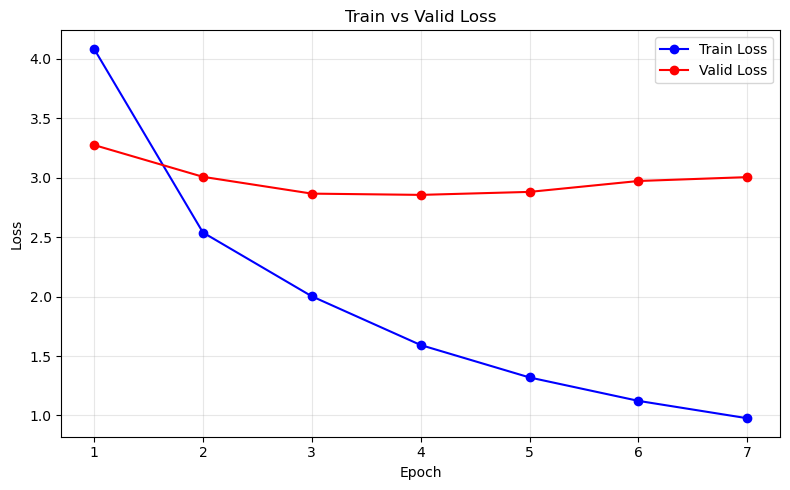

In [327]:
import json
import matplotlib.pyplot as plt

# history 불러오기
with open(os.path.join('model', 'transformer-history.json')) as f:
    history = json.load(f)

# 시각화
epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
plt.plot(epochs, history['valid_loss'],   'r-o', label='Valid Loss')
plt.title('Train vs Valid Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join('model', 'loss.png'), dpi=150)
plt.show()

```
최종
Hyperparameters
> n_layers: 1
> d_model: 256
> n_heads: 8
> d_ff: 1024
> dropout: 0.2

Training Parameters
> Warmup Steps: 1000
> Batch Size: 64
> Epoch At: 7
```

# Step 7. 성능 측정하기(BLEU Score)

In [330]:
#모델 불러오기
transformer.load_state_dict(torch.load("model/best_transformer.pt"))
transformer.to(device)
transformer.eval()

Transformer(
  (enc_emb): Embedding(5000, 256)
  (dec_emb): Embedding(5000, 256)
  (do): Dropout(p=0.2, inplace=False)
  (encoder): Encoder(
    (enc_layers): ModuleList(
      (0): EncoderLayer(
        (enc_self_attn): MultiHeadAttention(
          (W_q): Linear(in_features=256, out_features=256, bias=True)
          (W_k): Linear(in_features=256, out_features=256, bias=True)
          (W_v): Linear(in_features=256, out_features=256, bias=True)
          (linear): Linear(in_features=256, out_features=256, bias=True)
        )
        (ffn): PoswiseFeedForwardNet(
          (fc1): Linear(in_features=256, out_features=1024, bias=True)
          (fc2): Linear(in_features=1024, out_features=256, bias=True)
          (relu): ReLU()
        )
        (norm_1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (norm_2): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (do): Dropout(p=0.2, inplace=False)
      )
    )
    (do): Dropout(p=0.2, inplace=False)
  )
  (de

In [334]:
import pandas as pd

test_que = pd.read_csv("chatbot/test.csv")
print(test_df.head())
print(test_df.shape)

                  Q                   A  label
0           취뽀하고 싶다             취직이나라뇨.      0
1  이별한지 2달 다 되어갑니다.   마음이 좀 차분해졌길 바랍니다.      1
2        시간이 가고 있나?    시간은 지금도 흐르고 있어요.      1
3           어찌해야 할까          차분히 생각해봐요.      1
4         뭐 좀 배워볼까봐  배우는 건 항상 즐거운 일이에요.      0
(119, 3)


In [350]:
!pip install git+https://github.com/haven-jeon/PyKoSpacing.git #한국어 후처리 라이브러리

  Cloning https://github.com/haven-jeon/PyKoSpacing.git to /tmp/pip-req-build-xbu1pkmh
  Running command git clone --filter=blob:none --quiet https://github.com/haven-jeon/PyKoSpacing.git /tmp/pip-req-build-xbu1pkmh
  Resolved https://github.com/haven-jeon/PyKoSpacing.git to commit b32a889cbd10b006d2f4aba118f0cd5b677e2979
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'pykospacing' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pykospacing'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for pykospacing: filename=pykospacing-0.5-py3-none-any.whl size=2286996 sha256=02727424210add329991169293a0e6e498399fd6c58524601790b470c555df0f
  Stored 

In [351]:
import torch
import re
from pykospacing import Spacing # 한국어 띄어쓰기 교정 라이브러리

def evaluate_sentence(sentence, model, token2idx, idx2token, tokenize_fn, 
                      max_len=50, start_id=1, end_id=2, pad_id=0, unk_id=3, device='cpu'):
    model.eval()
    spacing = Spacing()

    # 1. 입력 문장 전처리 및 수치화
    # preprocess_sentence 함수가 정의되어 있다고 가정합니다.
    sentence = preprocess_sentence(sentence) 
    src_tokens = tokenize_fn(sentence)
    src_ids = [token2idx.get(token, unk_id) for token in src_tokens]
    
    # 길이 조절 및 패딩
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [pad_id] * (max_len - len(src_ids))
    src = torch.tensor([src_ids], dtype=torch.long).to(device)

    # 2. Greedy Decoding 시작
    output = [start_id]

    with torch.no_grad():
        for _ in range(max_len - 1):
            tgt_in = torch.tensor([output], dtype=torch.long).to(device)
            
            # 마스크 생성 (generate_masks 함수가 정의되어 있어야 함)
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

            # 모델 추론
            predictions, _, _, _ = model(
                src,
                tgt_in,
                enc_mask.to(device),
                dec_enc_mask.to(device),
                dec_mask.to(device)
            )

            # 마지막 시점의 확률이 가장 높은 토큰 선택
            pred_id = predictions[:, -1, :].argmax(dim=-1).item()

            if pred_id == end_id:
                break
            output.append(pred_id)

    # 3. 후처리 (Post-processing) - 핵심 개선 부분
    # 특수 토큰 제외하고 토큰 리스트 생성
    result_tokens = [idx2token.get(idx, "") for idx in output if idx not in [pad_id, start_id, end_id]]
    
    # [개선] MeCab 토큰은 공백 없이 합친 후 띄어쓰기 라이브러리로 교정
    combined_result = "".join(result_tokens)
    
    # 띄어쓰기 교정 적용 (PyKoSpacing 사용)
    # 라이브러리가 없다면 그냥 combined_result를 반환해도 지금보다 훨씬 자연스럽습니다.
    try:
        final_sentence = spacing(combined_result)
    except:
        final_sentence = combined_result

    # 문장 부호 앞 불필요한 공백 제거
    final_sentence = re.sub(r"\s+([.,!?;:])", r"\1", final_sentence).strip()

    return final_sentence

/opt/conda/lib/python3.12/site-packages/pykospacing/kospacing.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
E0000 00:00:1773382010.116791     127 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773382010.178234     127 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [342]:
idx2token = {idx: token for token, idx in vocab.items()}
idx2token

{0: '<pad>',
 1: '<start>',
 2: '<end>',
 3: '<unk>',
 4: '.',
 5: '이',
 6: '하',
 7: '는',
 8: '을',
 9: '세요',
 10: '가',
 11: '어',
 12: '고',
 13: '좋',
 14: '거',
 15: '해',
 16: '보',
 17: '있',
 18: '은',
 19: '지',
 20: '?',
 21: '아',
 22: '도',
 23: '나',
 24: '게',
 25: '에',
 26: '겠',
 27: '예요',
 28: '어요',
 29: '사람',
 30: '다',
 31: '를',
 32: '같',
 33: '한',
 34: '죠',
 35: '네요',
 36: '싶',
 37: '면',
 38: '안',
 39: '수',
 40: '네',
 41: '없',
 42: '사랑',
 43: '것',
 44: '봐요',
 45: '의',
 46: '아요',
 47: '잘',
 48: '말',
 49: '는데',
 50: '친구',
 51: '할',
 52: '않',
 53: '주',
 54: '생각',
 55: '되',
 56: '했',
 57: '일',
 58: '만',
 59: '었',
 60: '마음',
 61: '기',
 62: '내',
 63: '더',
 64: '너무',
 65: '들',
 66: '남자',
 67: '여자',
 68: '연락',
 69: '이별',
 70: '해요',
 71: '힘들',
 72: '으면',
 73: '남',
 74: '먹',
 75: '때',
 76: '길',
 77: '한테',
 78: '에요',
 79: '좀',
 80: '에서',
 81: '으로',
 82: '시간',
 83: '많',
 84: '썸',
 85: '야',
 86: '많이',
 87: '았',
 88: '!',
 89: '짝',
 90: '저',
 91: '받',
 92: '로',
 93: '뭐',
 94: '요',
 95: '건',
 96: '

### BLEU Score
- NLTK를 활용한 BLEU Score  
  : nltk가 BLEU Score를 지원함
- N-gram 측정 방식
  : 
- 표기  
  : 0~1 또는 백분율
- 해석
  : 보통 논문은 20 ~ 40점  
  : 50점을 넘으면 굉장히 좋은 번역기  

In [355]:
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.0/802.0 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [nltk]1/2 [nltk]


In [357]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# 1. NLTK 설치 확인 후 함수 정의
def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    # reference: ['나', '는', '밥', '을', '먹었다'] (정답 토큰 리스트)
    # candidate: ['나', '는', '밥', '을', '먹음'] (예측 토큰 리스트)
    return sentence_bleu([reference], 
                         candidate, 
                         weights=weights, 
                         smoothing_function=SmoothingFunction().method1)

In [371]:
results = []

for i in range(20):
    print(i)
    question = test_df.loc[i, "Q"]
    answer = test_df.loc[i, "A"]

    pred = evaluate_sentence(
        question,
        transformer,
        vocab,
        idx2token,
        mecab.morphs,
        max_len=MAX_LEN
    )

    # BLEU 점수 계산을 위한 토큰화
    ref_tokens = mecab.morphs(answer)
    pred_tokens = mecab.morphs(pred_sentence)

    # BLEU 점수 계산
    score = calculate_bleu(ref_tokens, pred_tokens)

    print(f"Q   : {question}")
    print(f"GOLD: {answer}")
    print(f"PRED: {pred}")
    print(f"BLEU: {score:.2f}")
    print("-" * 50)

    # 결과 저장
    results.append({
        'question': question,
        'gold': answer,
        'pred': pred_sentence,
        'bleu': score
    })

0
Q   : 취뽀하고 싶다
GOLD: 취직이나라뇨.
PRED: 할 수 있을 거예요.
BLEU: 0.04
--------------------------------------------------
1
Q   : 이별한지 2달 다 되어갑니다.
GOLD: 마음이 좀 차분해졌길 바랍니다.
PRED: 이별은 실감이 나겠네요.
BLEU: 0.03
--------------------------------------------------
2
Q   : 시간이 가고 있나?
GOLD: 시간은 지금도 흐르고 있어요.
PRED: 거예요.
BLEU: 0.13
--------------------------------------------------
3
Q   : 어찌해야 할까
GOLD: 차분히 생각해봐요.
PRED: 할 수 있을 거예요.
BLEU: 0.04
--------------------------------------------------
4
Q   : 뭐 좀 배워볼까봐
GOLD: 배우는 건 항상 즐거운 일이에요.
PRED: 먹고 맛있어요
BLEU: 0.03
--------------------------------------------------
5
Q   : 오늘 뭐 입지?
GOLD: 옷이요.
PRED: 하게 입어도 멋져요.
BLEU: 0.04
--------------------------------------------------
6
Q   : 연락 없더니 갑자기 왜 만나자고 하지?
GOLD: 이렇게 고민하게 만들려고 그랬나봐요.
PRED: 지 않아요.
BLEU: 0.02
--------------------------------------------------
7
Q   : 반지 선물하려고
GOLD: 로맨틱하네요.
PRED: 좋죠.
BLEU: 0.04
--------------------------------------------------
8
Q   : 거의 매일 술
GOLD: 술 많이 드시면 더 무너져요.
PRED: 먹어보세요.
BLEU: 0.02
------

**그럴싸한 응답**
```
1
Q   : 이별한지 2달 다 되어갑니다.
GOLD: 마음이 좀 차분해졌길 바랍니다.
PRED: 이별은 실감이 나겠네요.
BLEU: 0.03
```
```
14
Q   : 맘을 추스리지 못하겠어
GOLD: 많이 힘들어 하고 있군요.
PRED: , 이제 빠져나 오세요.
BLEU: 0.03
```

In [374]:
# BLEU 점수 기준 내림차순 정렬 (높은 점수가 위로)
results.sort(key=lambda x: x['bleu'], reverse=True)

# 상위 20개 출력
print(f"\n{'='*25} 상위 20 결과 (Best 20) {'='*25}\n")

for i, res in enumerate(results[:20]):
    print(f"Rank {i+1} [BLEU: {res['bleu']:.4f}]")
    print(f"Q    : {res['question']}")
    print(f"GOLD : {res['gold']}")
    print(f"PRED : {res['pred']}")
    print("-" * 60)

# 전체 평균 점수도 계산
avg_bleu = sum([r['bleu'] for r in results]) / len(results)
print(f"\n전체 데이터 평균 BLEU Score: {avg_bleu:.4f}")


========================= 상위 100개 결과 (Best 20) =========================

Rank 1 [BLEU: 0.1317]
Q    : 시간이 가고 있나?
GOLD : 시간은 지금도 흐르고 있어요.
PRED : 일 수도 있어요.
------------------------------------------------------------
Rank 2 [BLEU: 0.0408]
Q    : 취뽀하고 싶다
GOLD : 취직이나라뇨.
PRED : 일 수도 있어요.
------------------------------------------------------------
Rank 3 [BLEU: 0.0408]
Q    : 어찌해야 할까
GOLD : 차분히 생각해봐요.
PRED : 일 수도 있어요.
------------------------------------------------------------
Rank 4 [BLEU: 0.0408]
Q    : 오늘 뭐 입지?
GOLD : 옷이요.
PRED : 일 수도 있어요.
------------------------------------------------------------
Rank 5 [BLEU: 0.0408]
Q    : 반지 선물하려고
GOLD : 로맨틱하네요.
PRED : 일 수도 있어요.
------------------------------------------------------------
Rank 6 [BLEU: 0.0408]
Q    : 좋아하는 애 상메가 무슨 뜻인지 모르겠어.
GOLD : 궁금할만 해요.
PRED : 일 수도 있어요.
------------------------------------------------------------
Rank 7 [BLEU: 0.0408]
Q    : 친구 같은 너
GOLD : 그런 친구가 오래가요.
PRED : 일 수도 있어요.
----------------------------------------

**결과**
- BLEU Score가 높다고 좋은 대답이라고 할 수는 없다.
- BLEU가 0.367일때, "스팸 전화 많이와 > 연락해보세요." 처럼 맥락에 맞지않는 대답을 내놓는다건가, 내용은 없고 "거예요"와 같은 대답에도 0.1062라는 Score를 준 것으로보아 chatbot에 적합한 평가지표라고는 할 수 없을 것 같다.
- 오히려 score가 비교적 낮은 수준 (0.03대)의 응답이 실제로 할 법한 응답으로 보인다.

**회고**
- 응답이 "일 수도 있어요."라는 내용이 없는 응답을 내놓는 경우가 많은데, 명사 또는 수식어를 1개 이상 포함하여 출력하도록 조건을 넣는 방법을 생각해볼 수 있을 것 같다.
- 챗봇에서는 하나의 질문에 여러 응답이 있을 수 있는데, 데이터셋에서는 1개의 질문에 1개의 응답이 매칭이되어 gold standard가 오로지 응답 1개로 나온다. 이는 평가 방법에도 영향을 주어 실제 인간이 판단하는 것과는 다른 점수가 매겨진다.
- 문맥 기반 평가, 의미가 담긴 답변인지 여부 등을 반영하는 평가 방법으로 새롭게 제시 되어야할 것으로 보인다. 